<a href="https://colab.research.google.com/github/Haniye-Rj/ML_predicting_compensation_software_developers/blob/main/ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OrdinalEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    KFold
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.feature_selection import (
    SelectKBest,
    f_regression
)

from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)




In [2]:
# Load data
df = pd.read_csv('/content/drive/MyDrive/UW/ML1/train.csv')

# Basic Info
print(df.info())
print(df.describe())

print(df)
print(df.columns)
print(df.isnull().sum().sort_values(ascending=False))



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 41 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   annual.pay.usd             2512 non-null   float64
 1   region                     2512 non-null   object 
 2   age.group                  2512 non-null   object 
 3   employment.type            2512 non-null   object 
 4   work.location              2512 non-null   object 
 5   education                  2512 non-null   object 
 6   is.dev.professional        2512 non-null   object 
 7   coding.years.total         2507 non-null   float64
 8   coding.years.professional  2501 non-null   float64
 9   experience.years           1649 non-null   float64
 10  dev.role                   2510 non-null   object 
 11  company.size               2511 non-null   object 
 12  people.manager             1653 non-null   object 
 13  industry                   1633 non-null   objec

In [3]:
df['annual.pay.usd'].describe()

,annual.pay.usd
count,2.512000e+03
mean,4.971296e+04
std,1.096162e+05
min,1.000000e+00
25%,1.621675e+04
50%,4.082850e+04
75%,6.558925e+04
max,4.773360e+06


In [4]:
# from google.colab import drive
# drive.mount('/content/drive')

In [5]:
# target
target = 'annual.pay.usd'

# numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# categorical columns
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print(num_cols)
print(cat_cols)

['annual.pay.usd', 'coding.years.total', 'coding.years.professional', 'experience.years', 'job.satisfaction']
['region', 'age.group', 'employment.type', 'work.location', 'education', 'is.dev.professional', 'dev.role', 'company.size', 'people.manager', 'industry', 'tech.purchase.influence', 'build.vs.buy', 'side.coding', 'how.learned.coding', 'prog.languages', 'databases', 'cloud.platforms', 'web.frameworks', 'other.tech', 'dev.tools', 'dev.environments', 'personal.os', 'work.os', 'project.mgmt.tools', 'comm.tools', 'ai.search.tools', 'ai.tools.used', 'uses.ai', 'ai.sentiment', 'ai.trust', 'ai.complex.rating', 'ai.job.threat', 'daily.search.time', 'daily.answer.time', 'cloud.hosting', 'first.help.source']


In [6]:
corr = df[num_cols].corr()

salary_corr = corr[target].sort_values(ascending=False)

print(salary_corr)

annual.pay.usd               1.000000
coding.years.professional    0.141798
coding.years.total           0.129913
experience.years             0.122328
job.satisfaction             0.029699
Name: annual.pay.usd, dtype: float64


In [7]:
# Replace '.' with '_' in all column names
df.columns = df.columns.str.replace('.', '_', regex=False)

# Check the result
print(df.columns)
df = df.rename(columns={'dev_type': 'dev.type'})
df

Index(['annual_pay_usd', 'region', 'age_group', 'employment_type',
       'work_location', 'education', 'is_dev_professional',
       'coding_years_total', 'coding_years_professional', 'experience_years',
       'dev_role', 'company_size', 'people_manager', 'industry',
       'tech_purchase_influence', 'build_vs_buy', 'side_coding',
       'how_learned_coding', 'prog_languages', 'databases', 'cloud_platforms',
       'web_frameworks', 'other_tech', 'dev_tools', 'dev_environments',
       'personal_os', 'work_os', 'project_mgmt_tools', 'comm_tools',
       'ai_search_tools', 'ai_tools_used', 'uses_ai', 'ai_sentiment',
       'ai_trust', 'ai_complex_rating', 'ai_job_threat', 'daily_search_time',
       'daily_answer_time', 'cloud_hosting', 'first_help_source',
       'job_satisfaction'],
      dtype='object')


,annual_pay_usd,region,age_group,employment_type,work_location,education,is_dev_professional,coding_years_total,coding_years_professional,experience_years,...,uses_ai,ai_sentiment,ai_trust,ai_complex_rating,ai_job_threat,daily_search_time,daily_answer_time,cloud_hosting,first_help_source,job_satisfaction
0,44529.0,R11,35-44,Freelance/Self-employed,In-person,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",I am a developer by profession,29.0,16.0,17.0,...,Yes,Indifferent,Somewhat trust,Very poor at handling complex tasks,No,60-120 minutes a day,15-30 minutes a day,Hybrid (on-prem and cloud),Traditional public search engine,7.0
1,82086.0,R05,35-44,Full-time,Remote,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",I am a developer by profession,17.0,14.0,13.0,...,"No, and I don't plan to",NaN,NaN,NaN,NaN,30-60 minutes a day,Less than 15 minutes a day,Cloud only (single or multi-cloud),Traditional public search engine,6.0
2,14223.0,R17,18-24,Full-time,Remote,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",I am a developer by profession,4.0,0.0,1.0,...,Yes,Very favorable,Neither trust nor distrust,NaN,I'm not sure,NaN,NaN,NaN,NaN,10.0
3,78010.0,R17,18-24,Full-time,Remote,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",I am a developer by profession,5.0,6.0,5.0,...,Yes,Very favorable,Highly trust,"Good, but not great at handling complex tasks",No,30-60 minutes a day,15-30 minutes a day,Cloud only (single or multi-cloud),A coworker,10.0
4,38539.0,R17,18-24,Full-time,Remote,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","I am not primarily a developer, but I write co...",6.0,4.0,3.0,...,Yes,Favorable,Somewhat distrust,Bad at handling complex tasks,I'm not sure,30-60 minutes a day,30-60 minutes a day,Cloud only (single or multi-cloud),AI-powered search (free),6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2507,774.0,R17,25-34,Full-time,Remote,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",I am a developer by profession,14.0,10.0,NaN,...,Yes,Indifferent,Neither trust nor distrust,Neither good or bad at handling complex tasks,No,NaN,NaN,NaN,NaN,NaN
2508,11545.0,R17,35-44,Full-time,Remote,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",I am a developer by profession,9.0,4.0,4.0,...,"No, and I don't plan to",NaN,NaN,NaN,NaN,Over 120 minutes a day,60-120 minutes a day,Cloud only (single or multi-cloud),Traditional public search engine,7.0
2509,25946.0,R13,25-34,Full-time,"Hybrid (some remote, some in-person)",Some college/university study without earning ...,I am a developer by profession,11.0,3.0,NaN,...,Yes,Indifferent,Somewhat distrust,Bad at handling complex tasks,No,NaN,NaN,NaN,NaN,NaN
2510,61077.0,R13,35-44,Full-time,Remote,Some college/university study without earning ...,I am a developer by profession,26.0,14.0,NaN,...,"No, but I plan to soon",Favorable,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN


In [8]:
# 1. Grouping logic
region_counts = df['region'].value_counts()
region_counts

,count
region,
R17,1108
R11,433
R13,212
R18,122
R03,114
R05,80
R06,75
R04,60
R16,60


In [9]:
rare_regions = region_counts[region_counts <= 30].index
rare_regions

Index(['R01', 'R12', 'R14', 'R07', 'R10', 'R15'], dtype='object', name='region')

In [10]:
df['region'] = df['region'].apply(lambda x: 'Other' if x in rare_regions else x)
df['region']
# 2. Aggregating the data (calculating the median for each group)
# We use median because of the outliers ($4.7M) in your dataset
plot_df = df.groupby('region')['annual_pay_usd'].median().reset_index()

# 3. Sorting the data by median pay
plot_df = plot_df.sort_values('annual_pay_usd', ascending=False)

# 4. Creating the Plotly Bar Chart
fig = px.bar(plot_df,
             x='region',
             y='annual_pay_usd',
             title='Median Annual Pay by Region (Grouped)',
             labels={'annual_pay_usd': 'Median Annual Pay (USD)', 'region': 'Region'},
             text_auto='.2s', # Displays values on top of bars
             color='annual_pay_usd', # Adds a color gradient
             color_continuous_scale='Viridis')

# 5. Applying the Log Scale to the Y-axis
fig.update_layout(yaxis_type="log",
                  xaxis={'categoryorder':'total descending'},
                  yaxis_title="Annual Pay USD (Log Scale)")

fig.show()

In [11]:
age_counts = df['age_group'].value_counts()
print(age_counts )

age_group
25-34    1220
35-44     641
18-24     509
45-54     120
55+        22
Name: count, dtype: int64


In [12]:
rare_age_groups = age_counts[age_counts < 30].index
df['age_group'] = df['age_group'].apply(lambda x: 'Other' if x in rare_age_groups else x)

# 2. Aggregating the data (calculating the median pay per age group)
# Using annual_pay_usd (new name)
plot_df = df.groupby('age_group')['annual_pay_usd'].median().reset_index()

# 3. Sorting the data by highest to lowest median pay
plot_df = plot_df.sort_values('annual_pay_usd', ascending=False)

# 4. Creating the Plotly Bar Chart
fig = px.bar(plot_df,
             x='age_group',
             y='annual_pay_usd',
             title='Median Annual Pay by Age Group',
             labels={'annual_pay_usd': 'Median Annual Pay (USD)', 'age_group': 'Age Group'},
             text_auto='.2s',
             color='annual_pay_usd',
             color_continuous_scale='Viridis')

# 5. Applying the Log Scale to the Y-axis
fig.update_layout(yaxis_type="log",
                  xaxis={'categoryorder':'total descending'},
                  yaxis_title="Annual Pay USD (Log Scale)")

fig.show()

In [13]:
employment_type_counts = df['employment_type'].value_counts()
print(employment_type_counts )

employment_type
Full-time                  2103
Freelance/Self-employed     294
Student                      69
Part-time                    34
Job-seeking                  12
Name: count, dtype: int64


In [14]:
# Dropping job_satisfaction and any temporary columns, risk of data leakage
df = df.drop(columns=['job_satisfaction','age_group','experience_years'], errors='ignore')

In [15]:
df.columns

Index(['annual_pay_usd', 'region', 'employment_type', 'work_location',
       'education', 'is_dev_professional', 'coding_years_total',
       'coding_years_professional', 'dev_role', 'company_size',
       'people_manager', 'industry', 'tech_purchase_influence', 'build_vs_buy',
       'side_coding', 'how_learned_coding', 'prog_languages', 'databases',
       'cloud_platforms', 'web_frameworks', 'other_tech', 'dev_tools',
       'dev_environments', 'personal_os', 'work_os', 'project_mgmt_tools',
       'comm_tools', 'ai_search_tools', 'ai_tools_used', 'uses_ai',
       'ai_sentiment', 'ai_trust', 'ai_complex_rating', 'ai_job_threat',
       'daily_search_time', 'daily_answer_time', 'cloud_hosting',
       'first_help_source'],
      dtype='object')

In [16]:
# Numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("NUMERICAL COLUMNS")
for col in numerical_cols:
    print(col)

print("CATEGORICAL COLUMNS")
# Categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

for col in categorical_cols:
    print(col)


numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns

corr = df[numeric_cols].corr()

fig = px.imshow(
    corr,
    text_auto=True,
    aspect="auto",
    title="Correlation Matrix"
)

fig.show()

NUMERICAL COLUMNS
annual_pay_usd
coding_years_total
coding_years_professional
CATEGORICAL COLUMNS
region
employment_type
work_location
education
is_dev_professional
dev_role
company_size
people_manager
industry
tech_purchase_influence
build_vs_buy
side_coding
how_learned_coding
prog_languages
databases
cloud_platforms
web_frameworks
other_tech
dev_tools
dev_environments
personal_os
work_os
project_mgmt_tools
comm_tools
ai_search_tools
ai_tools_used
uses_ai
ai_sentiment
ai_trust
ai_complex_rating
ai_job_threat
daily_search_time
daily_answer_time
cloud_hosting
first_help_source


In [17]:
# Scatter plot to see the difference between Total and Professional years
fig = px.scatter(df, x='coding_years_total', y='coding_years_professional',
                 color='annual_pay_usd',
                 title='Total vs Professional Coding Years',
                 labels={'coding_years_total': 'Total Years', 'coding_years_professional': 'Professional Years'},
                 trendline="ols") # Adds a linear trend line
fig.show()

It is highly correlated with coding_years_total (0.88)
It likely carries overlapping information
Your VIF analysis already suggests the remaining two features are stable together


In [18]:
cols_to_drop = ['coding_years_total']
df = df.drop(columns=cols_to_drop, errors='ignore')
df.columns

Index(['annual_pay_usd', 'region', 'employment_type', 'work_location',
       'education', 'is_dev_professional', 'coding_years_professional',
       'dev_role', 'company_size', 'people_manager', 'industry',
       'tech_purchase_influence', 'build_vs_buy', 'side_coding',
       'how_learned_coding', 'prog_languages', 'databases', 'cloud_platforms',
       'web_frameworks', 'other_tech', 'dev_tools', 'dev_environments',
       'personal_os', 'work_os', 'project_mgmt_tools', 'comm_tools',
       'ai_search_tools', 'ai_tools_used', 'uses_ai', 'ai_sentiment',
       'ai_trust', 'ai_complex_rating', 'ai_job_threat', 'daily_search_time',
       'daily_answer_time', 'cloud_hosting', 'first_help_source'],
      dtype='object')

In [19]:
df['work_location'].value_counts()

,count
work_location,
Remote,1479
"Hybrid (some remote, some in-person)",809
In-person,224


In [20]:
# Aggregating the data (calculating the median for each group)
plot_df = df.groupby('work_location')['annual_pay_usd'].median().reset_index()

# Sorting the data by median pay
plot_df = plot_df.sort_values('annual_pay_usd', ascending=False)

fig = px.bar(plot_df,
             x='work_location',
             y='annual_pay_usd',
             title='Median Annual Pay by work_location',
             labels={'annual_pay_usd': 'Median Annual Pay (USD)', 'work_location': 'work_location'},
             text_auto='.2s', # Displays values on top of bars
             color='annual_pay_usd', # Adds a color gradient
             color_continuous_scale='Viridis')

# 5. Applying the Log Scale to the Y-axis
fig.update_layout(yaxis_type="log",
                  xaxis={'categoryorder':'total descending'},
                  yaxis_title="Annual Pay USD (Log Scale)")

fig.show()

In [21]:
df['education'].value_counts()

,count
education,
"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",1178
"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",734
Some college/university study without earning a degree,318
"Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)",140
"Professional degree (JD, MD, Ph.D, Ed.D, etc.)",71
"Associate degree (A.A., A.S., etc.)",35
Primary/elementary school,24
Something else,12


unnecessary complexity (more columns) without adding any predictive "signal." combining them or dropping???


In [22]:
# Group education levels
def group_education(edu):
    if 'Master’s' in edu:
        return 'Graduate (Master)'
    elif 'Professional' in edu:
        return 'Post-Graduate (PhD/MD)'
    elif 'Bachelor’s' in edu:
        return 'Undergraduate (Bachelor)'
    elif 'Some college' in edu or 'Associate' in edu:
        return 'Undergrad / Technical'
    else:
        return 'Secondary or lower'

# Apply transformation
df['education'] = df['education'].apply(group_education)

print(df['education'].value_counts())

# Count values
edu_counts = df['education'].value_counts().reset_index()

edu_counts.columns = ['Education Level', 'Count']

# Plot
fig = px.bar(
    edu_counts,
    x='Education Level',
    y='Count',
    text='Count',
    title='Distribution of Education Levels',
)

fig.update_layout(
    xaxis_title='Education Group',
    yaxis_title='Number of People',
    template='plotly_white'
)

fig.show()

education
Graduate (Master)           1178
Undergraduate (Bachelor)     734
Undergrad / Technical        353
Secondary or lower           176
Post-Graduate (PhD/MD)        71
Name: count, dtype: int64


In [23]:
salary_by_edu = df.groupby('education')['annual_pay_usd'].median().reset_index()

fig = px.bar(
    salary_by_edu,
    x='education',
    y='annual_pay_usd',
    text_auto='.2s',
    title='Average Salary by Education Level'
)

fig.update_layout(
    xaxis_title='Education Level',
    yaxis_title='Average Salary (USD)',
    template='plotly_white'
)

fig.show()

In [24]:
df = df.drop(columns='is_dev_professional', errors='ignore')
#because we have dev_role instead

In [25]:
df['dev_role'] = df['dev_role'].dropna()
df['dev_role'].value_counts()


,count
dev_role,
"Developer, back-end",735
"Developer, full-stack",675
"Developer, front-end",227
"Developer, mobile",116
"Developer, desktop or enterprise applications",109
Other,73
"Developer, QA or test",70
DevOps specialist,66
Data engineer,59


In [26]:
def group_dev_role_better(role):
    role = str(role).lower()

    if any(x in role for x in [
        'senior executive', 'executive', 'c-suite', 'vp',
        'engineering manager', 'manager', 'product manager'
    ]):
        return 'Leadership & Management'

    elif any(x in role for x in [
        'data scientist', 'machine learning', 'ai',
        'data engineer', 'data analyst', 'analytics'
    ]):
        return 'Data & AI'

    elif any(x in role for x in [
        'devops', 'cloud', 'infrastructure',
        'site reliability', 'sre', 'system administrator'
    ]):
        return 'DevOps & Cloud'

    elif any(x in role for x in [
        'back-end', 'backend', 'server'
    ]):
        return 'Backend'

    elif any(x in role for x in [
        'front-end', 'frontend'
    ]):
        return 'Frontend'

    elif any(x in role for x in [
        'full-stack', 'full stack'
    ]):
        return 'Full-stack'

    elif any(x in role for x in [
        'mobile', 'android', 'ios'
    ]):
        return 'Mobile'

    elif any(x in role for x in [
        'embedded', 'iot', 'hardware'
    ]):
        return 'Embedded & Hardware'

    elif any(x in role for x in [
        'game', 'graphics', 'blockchain'
    ]):
        return 'Specialized Software'

    elif any(x in role for x in [
        'qa', 'test', 'quality'
    ]):
        return 'QA & Testing'

    elif any(x in role for x in [
        'research', 'academic'
    ]):
        return 'Research'

    elif any(x in role for x in [
        'student', 'educator', 'teacher'
    ]):
        return 'Education / Student'

    else:
        return 'Other'
df['dev_role'] = df['dev_role'].apply(group_dev_role_better)

df['dev_role'] = df['dev_role'].dropna()
df['dev_role'].value_counts()


,count
dev_role,
Backend,735
Full-stack,675
Other,252
Frontend,227
Data & AI,130
Mobile,116
DevOps & Cloud,109
QA & Testing,70
Leadership & Management,61


In [27]:
# def group_dev_role(role):
#     role = str(role).lower()

#     if any(x in role for x in ['back-end', 'devops', 'cloud', 'infrastructure', 'administrator']):
#         return 'Back-end & Infrastructure'

#     elif any(x in role for x in ['full-stack', 'front-end']):
#         return 'Full-stack & Front-end'

#     elif any(x in role for x in ['data', 'machine learning', 'ai', 'scientist', 'analyst']):
#         return 'Data & AI'

#     elif any(x in role for x in ['mobile', 'desktop', 'embedded', 'game', 'graphics', 'blockchain']):
#         return 'Mobile & Specialized App'

#     elif any(x in role for x in ['manager', 'executive', 'vp', 'c-suite']):
#         return 'Leadership & Management'

#     elif 'test' in role or 'qa' in role:
#         return 'QA & Testing'
#     elif 'research' in role:
#         return 'Research'

#     else:
#         return 'Other '
# df['dev_role'] = df['dev_role'].apply(group_dev_role)

# df['dev_role'] = df['dev_role'].dropna()
# df['dev_role'].value_counts()


In [28]:
salary_by_edu = df.groupby('dev_role')['annual_pay_usd'].median().reset_index()

fig = px.bar(
    salary_by_edu,
    x='dev_role',
    y='annual_pay_usd',
    text_auto='.2s',
    title='Average Salary by dev_role'
)

fig.update_layout(
    xaxis_title='dev_role',
    yaxis_title='Average Salary (USD)',
    template='plotly_white'
)

fig.show()

In [29]:
df['company_size'] = df['company_size'].dropna()
df['company_size'].value_counts()

,count
company_size,
20 to 99 employees,651
100 to 499 employees,556
"1,000 to 4,999 employees",334
10 to 19 employees,220
"10,000 or more employees",212
2 to 9 employees,195
500 to 999 employees,148
"5,000 to 9,999 employees",84
"Just me - I am a freelancer, sole proprietor, etc.",81


In [30]:
def map_company_size(size):
    if size in ['Just me - I am a freelancer, sole proprietor, etc.', '2 to 9 employees']:
        return 1 # Small/Freelance
    elif size == '10 to 19 employees':
        return 2 # Small-Mid
    elif size == '20 to 99 employees':
        return 3 # Mid
    elif size in ['100 to 499 employees', '500 to 999 employees']:
        return 4 # Large
    elif size in ['1,000 to 4,999 employees', '5,000 to 9,999 employees', '10,000 or more employees']:
        return 5 # Enterprise
    else:
        return 3 # Default for 'I don’t know' (The Mode: 20-99)

# Apply the mapping
df['company_size'] = df['company_size'].apply(map_company_size)

In [31]:
df['company_size'] = df['company_size'].dropna()
df['company_size']


,company_size
0,1
1,3
2,4
3,4
4,4
...,...
2507,5
2508,2
2509,3
2510,5


In [32]:
drop_cols = [
    'cloud_hosting',
    'daily_answer_time',
    'daily_search_time',
    'first_help_source',
    'other_tech',
    'ai_tools_used',
    'ai_complex_rating',
    'ai_trust',
    'web_frameworks',
    'cloud_platforms',
    'ai_search_tools',
    'ai_sentiment',
    'ai_job_threat',
    'databases',
    'industry',
    'project_mgmt_tools',
    'dev_tools',
    'people_manager'

]


df = df.drop(columns=drop_cols)

In [33]:
df

,annual_pay_usd,region,employment_type,work_location,education,coding_years_professional,dev_role,company_size,tech_purchase_influence,build_vs_buy,side_coding,how_learned_coding,prog_languages,dev_environments,personal_os,work_os,comm_tools,uses_ai
0,44529.0,R11,Freelance/Self-employed,In-person,Graduate (Master),16.0,Other,1,I have a great deal of influence,Is ready-to-go but also customizable for growt...,Bootstrapping a business;Freelance/contract wo...,Books / Physical media;Colleague;Friend or fam...,C++;Dart;Delphi;HTML/CSS;JavaScript;PHP;SQL,"Android Studio;Netbeans;Rad Studio (Delphi, C+...",Debian;Other Linux-based,Debian;Other Linux-based,Whatsapp,Yes
1,82086.0,R05,Full-time,Remote,Undergraduate (Bachelor),14.0,Backend,3,I have little or no influence,Is ready-to-go but also customizable for growt...,Contribute to open-source projects;Hobby,Books / Physical media;Colleague;Online Course...,Bash/Shell (all shells);HTML/CSS;Java;JavaScri...,IntelliJ IDEA;Vim;Visual Studio Code,Ubuntu,Ubuntu,Google Meet;Microsoft Teams;Slack,"No, and I don't plan to"
2,14223.0,R17,Full-time,Remote,Undergraduate (Bachelor),0.0,Full-stack,4,I have some influence,Is set up to be customized and needs to be eng...,Freelance/contract work;Professional developme...,On the job training;Online Courses or Certific...,HTML/CSS;JavaScript;Python;TypeScript,Android Studio;PyCharm;WebStorm,Windows,Other (please specify):,Slack;Telegram;Zoom,Yes
3,78010.0,R17,Full-time,Remote,Graduate (Master),6.0,Research,4,I have some influence,Is set up to be customized and needs to be eng...,School or academic work,"Books / Physical media;School (i.e., Universit...",Java;Python;SQL,Jupyter Notebook/JupyterLab;Visual Studio Code,MacOS,MacOS,NaN,Yes
4,38539.0,R17,Full-time,Remote,Undergraduate (Bachelor),4.0,Other,4,I have some influence,Is ready-to-go but also customizable for growt...,Freelance/contract work,Online Courses or Certification;Other online r...,Python,Notepad++;Sublime Text;Visual Studio Code,MacOS;Windows;Windows Subsystem for Linux (WSL),Ubuntu;Windows;Windows Subsystem for Linux (WSL),Google Meet;Microsoft Teams;Signal;Slack;Telegram,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2507,774.0,R17,Full-time,Remote,Undergraduate (Bachelor),10.0,Full-stack,5,I have a great deal of influence,Is ready-to-go but also customizable for growt...,Hobby,Books / Physical media;Coding Bootcamp;On the ...,C#;SQL,Visual Studio,Windows,Windows,Microsoft Teams,Yes
2508,11545.0,R17,Full-time,Remote,Undergraduate (Bachelor),4.0,Mobile,2,I have little or no influence,NaN,Bootstrapping a business;Professional developm...,Coding Bootcamp;Colleague;Friend or family mem...,Dart,Android Studio;Xcode,Android;MacOS,Android;MacOS;iOS,Google Meet;Telegram,"No, and I don't plan to"
2509,25946.0,R13,Full-time,"Hybrid (some remote, some in-person)",Undergrad / Technical,3.0,Full-stack,3,I have some influence,Is ready-to-go but also customizable for growt...,Hobby,"Other online resources (e.g., videos, blogs, f...",C#;HTML/CSS;JavaScript;PHP;Python;SQL;TypeScript,Android Studio;PhpStorm;PyCharm;Sublime Text;V...,Windows,Windows,Discord;Microsoft Teams,Yes
2510,61077.0,R13,Full-time,Remote,Undergrad / Technical,14.0,Frontend,5,I have some influence,Out-of-the-box is ready to go with little need...,Contribute to open-source projects;Hobby,Books / Physical media;Friend or family member...,Bash/Shell (all shells);JavaScript;Perl;Python...,Vim;Visual Studio Code,Debian,Debian,Discord;Google Meet;IRC;Matrix;Slack,"No, but I plan to soon"


In [34]:
df['prog_languages'].value_counts()

,count
prog_languages,
HTML/CSS;JavaScript;TypeScript,94
Java,48
Python,39
HTML/CSS;JavaScript;PHP;SQL,32
C#,32
...,...
HTML/CSS;Python;TypeScript,1
Bash/Shell (all shells);Kotlin;Scala;TypeScript,1
C++;HTML/CSS;Java;Rust;TypeScript,1


In [35]:
df.drop(columns=['comm_tools'], inplace=True)

In [36]:
df['uses_ai'].value_counts()

# 1. Map 'Yes' to 1 and 'No' to 0
# We use .fillna(0) because if someone skipped the question,
# it usually means they are not an active AI user.
df['uses_ai'] = df['uses_ai'].map({'Yes': 1, 'No': 0}).fillna(0).astype(int)
df['uses_ai'].value_counts()


,count
uses_ai,
1,1727
0,785


In [37]:

# We take the first OS listed as a proxy for the main environment
df['work_os'] = df['work_os'].fillna('Unknown').str.split(';').str[0]

# Filter out 'Other (please specify):' to keep the chart clean
os_sal = df[df['work_os'] != 'Other (please specify):']
os_sal = os_sal.groupby('work_os')['annual_pay_usd'].median().reset_index()
os_sal = os_sal.sort_values('annual_pay_usd', ascending=False)

fig2 = px.bar(os_sal, x='work_os', y='annual_pay_usd',
             title='Median Salary by Primary Operating System',
             color='annual_pay_usd', text_auto='.2s')
fig2.show()

In [38]:
def group_os(os):
    os = str(os)
    if os in ['MacOS', 'Arch', 'Debian']:
        return 'OS_Tier_1_Premium'
    elif any(x in os for x in ['Red Hat', 'Fedora', 'Ubuntu', 'Android']):
        return 'OS_Tier_2_Standard_Linux'
    elif os in ['Windows', 'Other', 'Unknown']:
        return 'OS_Tier_3_Windows_Base'
    else:
        return 'OS_Tier_4_Specialized'

# Apply the grouping
df['work_os'] = df['work_os'].apply(group_os)

# Quick check on the new medians to ensure the groups make sense
print(df.groupby('work_os')['annual_pay_usd'].median().sort_values(ascending=False))

work_os
OS_Tier_1_Premium           50446.0
OS_Tier_2_Standard_Linux    37351.0
OS_Tier_3_Windows_Base      35942.0
OS_Tier_4_Specialized       32443.0
Name: annual_pay_usd, dtype: float64


In [39]:
df['tech_purchase_influence'].value_counts()

,count
tech_purchase_influence,
I have some influence,1073
I have little or no influence,1047
I have a great deal of influence,385


In [40]:
# Fill null values with the mode (most frequent value)
df['tech_purchase_influence'] = df['tech_purchase_influence'].fillna(df['tech_purchase_influence'].mode()[0])

In [41]:
# 1. Calculate the median salary for each influence level
# We use median to protect against outliers (the $5M salaries)
influence_sal = df.groupby('tech_purchase_influence')['annual_pay_usd'].median().reset_index()

# 2. Sort the categories logically (Low to High Influence)
# This makes the "step-up" in salary easier to see
influence_order = [
    'I have little or no influence',
    'I have some influence',
    'I have a great deal of influence'
]

# Ensure the dataframe follows this order
influence_sal['tech_purchase_influence'] = pd.Categorical(
    influence_sal['tech_purchase_influence'],
    categories=influence_order,
    ordered=True
)
influence_sal = influence_sal.sort_values('tech_purchase_influence')

# 3. Create the Bar Chart
fig = px.bar(influence_sal,
             x='tech_purchase_influence',
             y='annual_pay_usd',
             title='Is Purchasing Power Linked to Higher Pay?',
             color='annual_pay_usd',
             text_auto='.2s', # Displays formatted thousands (e.g., 45k)
             color_continuous_scale='Viridis',
             labels={'annual_pay_usd': 'Median Annual Pay (USD)',
                     'tech_purchase_influence': 'Level of Influence'})

fig.update_layout(xaxis_title="Influence Level", yaxis_title="Median Salary")
fig.show()

In [42]:
# 1. Create the binary flag
# We use a lambda to catch both 'some' and 'great deal'
df['has_influence'] = df['tech_purchase_influence'].apply(
    lambda x: 1 if x in ['I have a great deal of influence'] else 0
)

# 2. Drop the original column to avoid redundancy
df.drop(columns=['tech_purchase_influence'], inplace=True)

# 3. Verify the new median split
print(df.groupby('has_influence')['annual_pay_usd'].median())

has_influence
0    38855.0
1    52909.0
Name: annual_pay_usd, dtype: float64


In [43]:
df['how_learned_coding'].value_counts()

,count
how_learned_coding,
"Books / Physical media;Online Courses or Certification;Other online resources (e.g., videos, blogs, forum, online community)",146
"Other online resources (e.g., videos, blogs, forum, online community)",137
"Online Courses or Certification;Other online resources (e.g., videos, blogs, forum, online community)",105
"Books / Physical media;Other online resources (e.g., videos, blogs, forum, online community)",105
"Books / Physical media;On the job training;Online Courses or Certification;Other online resources (e.g., videos, blogs, forum, online community)",78
...,...
Books / Physical media;Friend or family member;Other (please specify):,1
"Books / Physical media;Friend or family member;On the job training;Other (please specify):;Other online resources (e.g., videos, blogs, forum, online community);School (i.e., University, College, etc)",1
Friend or family member,1


In [44]:
# Create binary flags for the most important learning methods
df['learned_school'] = df['how_learned_coding'].str.contains('School', case=False, na=False).astype(int)
df['learned_online'] = df['how_learned_coding'].str.contains('Online Courses|Other online resources', case=False, na=False).astype(int)
df['learned_bootcamp'] = df['how_learned_coding'].str.contains('Coding Bootcamp', case=False, na=False).astype(int)
df['learned_on_job'] = df['how_learned_coding'].str.contains('On the job training', case=False, na=False).astype(int)

# Optional: Create a 'Self-Taught Only' flag (No school, no bootcamp)
df['is_purely_self_taught'] = ((df['learned_online'] == 1) &
                               (df['learned_school'] == 0) &
                               (df['learned_bootcamp'] == 0)).astype(int)

In [45]:

# List of the new flags we just made
edu_methods = ['learned_school', 'learned_online', 'learned_bootcamp', 'learned_on_job', 'is_purely_self_taught']

# Calculate median salary for each
method_salaries = []
for method in edu_methods:
    median_pay = df[df[method] == 1]['annual_pay_usd'].median()
    count = df[df[method] == 1].shape[0]
    method_salaries.append({'Method': method, 'Median_Salary': median_pay, 'Count': count})

# Create DataFrame for plotting
df_plot = pd.DataFrame(method_salaries).sort_values('Median_Salary', ascending=False)

# Plot
fig = px.bar(df_plot, x='Method', y='Median_Salary',
             color='Median_Salary', text_auto='.2s',
             title='Median Salary by Learning Method (Binary Groups)',
             labels={'Median_Salary': 'Median Annual Pay (USD)'})
fig.show()

In [46]:
df

,annual_pay_usd,region,employment_type,work_location,education,coding_years_professional,dev_role,company_size,build_vs_buy,side_coding,...,dev_environments,personal_os,work_os,uses_ai,has_influence,learned_school,learned_online,learned_bootcamp,learned_on_job,is_purely_self_taught
0,44529.0,R11,Freelance/Self-employed,In-person,Graduate (Master),16.0,Other,1,Is ready-to-go but also customizable for growt...,Bootstrapping a business;Freelance/contract wo...,...,"Android Studio;Netbeans;Rad Studio (Delphi, C+...",Debian;Other Linux-based,OS_Tier_1_Premium,1,1,1,0,0,0,0
1,82086.0,R05,Full-time,Remote,Undergraduate (Bachelor),14.0,Backend,3,Is ready-to-go but also customizable for growt...,Contribute to open-source projects;Hobby,...,IntelliJ IDEA;Vim;Visual Studio Code,Ubuntu,OS_Tier_2_Standard_Linux,0,0,0,1,0,0,1
2,14223.0,R17,Full-time,Remote,Undergraduate (Bachelor),0.0,Full-stack,4,Is set up to be customized and needs to be eng...,Freelance/contract work;Professional developme...,...,Android Studio;PyCharm;WebStorm,Windows,OS_Tier_4_Specialized,1,0,1,1,0,1,0
3,78010.0,R17,Full-time,Remote,Graduate (Master),6.0,Research,4,Is set up to be customized and needs to be eng...,School or academic work,...,Jupyter Notebook/JupyterLab;Visual Studio Code,MacOS,OS_Tier_1_Premium,1,0,1,0,0,0,0
4,38539.0,R17,Full-time,Remote,Undergraduate (Bachelor),4.0,Other,4,Is ready-to-go but also customizable for growt...,Freelance/contract work,...,Notepad++;Sublime Text;Visual Studio Code,MacOS;Windows;Windows Subsystem for Linux (WSL),OS_Tier_2_Standard_Linux,1,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2507,774.0,R17,Full-time,Remote,Undergraduate (Bachelor),10.0,Full-stack,5,Is ready-to-go but also customizable for growt...,Hobby,...,Visual Studio,Windows,OS_Tier_3_Windows_Base,1,1,1,1,1,1,0
2508,11545.0,R17,Full-time,Remote,Undergraduate (Bachelor),4.0,Mobile,2,NaN,Bootstrapping a business;Professional developm...,...,Android Studio;Xcode,Android;MacOS,OS_Tier_2_Standard_Linux,0,0,0,1,1,1,0
2509,25946.0,R13,Full-time,"Hybrid (some remote, some in-person)",Undergrad / Technical,3.0,Full-stack,3,Is ready-to-go but also customizable for growt...,Hobby,...,Android Studio;PhpStorm;PyCharm;Sublime Text;V...,Windows,OS_Tier_3_Windows_Base,1,0,0,1,0,0,1
2510,61077.0,R13,Full-time,Remote,Undergrad / Technical,14.0,Frontend,5,Out-of-the-box is ready to go with little need...,Contribute to open-source projects;Hobby,...,Vim;Visual Studio Code,Debian,OS_Tier_1_Premium,0,0,1,1,0,1,0


doesnt look importand

In [47]:
# List of raw text/multi-select columns to drop
cols_to_remove = [
    'build_vs_buy',
    'how_learned_coding',
    'personal_os',
    'learned_school', 'learned_online', 'learned_bootcamp', 'learned_on_job', 'is_purely_self_taught'
]

# Execute the drop
df = df.drop(columns=cols_to_remove)

df.columns

Index(['annual_pay_usd', 'region', 'employment_type', 'work_location',
       'education', 'coding_years_professional', 'dev_role', 'company_size',
       'side_coding', 'prog_languages', 'dev_environments', 'work_os',
       'uses_ai', 'has_influence'],
      dtype='object')

In [48]:
# Convert multi-label categories into dummy variables
side_dummies = df['side_coding'].str.get_dummies(sep=';')

# Add target column temporarily
side_dummies['annual_pay_usd'] = df['annual_pay_usd']

# Correlation with salary
corr_with_salary = side_dummies.corr()['annual_pay_usd'].sort_values(ascending=False)

print(corr_with_salary)

annual_pay_usd                                                         1.000000
Bootstrapping a business                                               0.052236
Contribute to open-source projects                                     0.042863
Freelance/contract work                                                0.007212
Hobby                                                                  0.006591
I don’t code outside of work                                           0.005978
Other (please specify):                                               -0.007686
School or academic work                                               -0.014404
Professional development or self-paced learning from online courses   -0.036511
Name: annual_pay_usd, dtype: float64


In [49]:
df = df.drop(columns=['side_coding'])


In [50]:
df = df.dropna(subset=['prog_languages'])

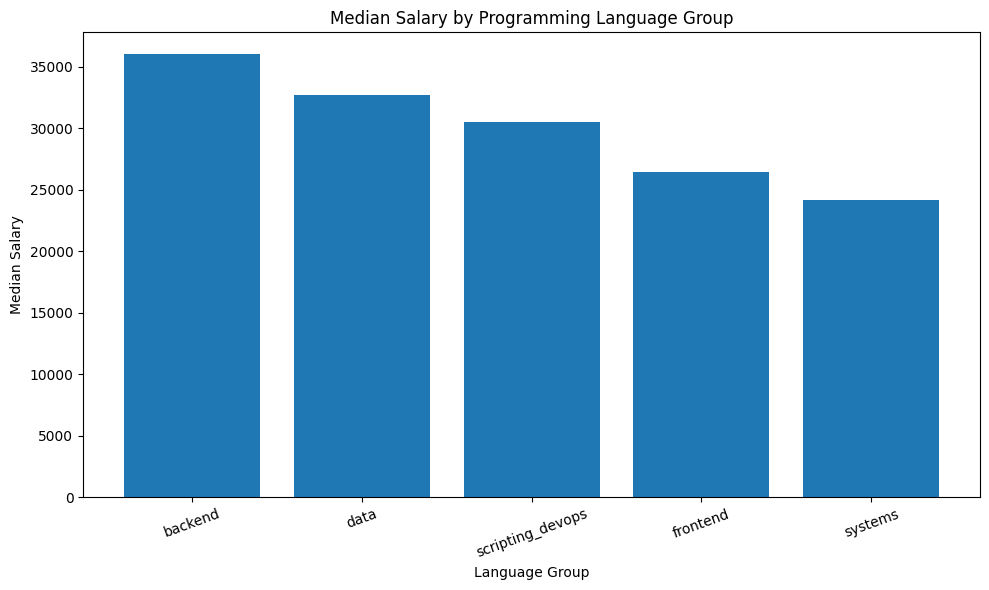

In [51]:


# -----------------------------
# LANGUAGE GROUPS
# -----------------------------
language_groups = {
    "frontend": [
        "HTML/CSS",
        "JavaScript",
        "TypeScript"
    ],

    "backend": [
        "Python",
        "Java",
        "PHP",
        "C#",
        "Go",
        "Ruby"
    ],

    "systems": [
        "C",
        "C++",
        "Rust"
    ],

    "data": [
        "SQL",
        "R",
        "Scala"
    ],

    "scripting_devops": [
        "Bash/Shell (all shells)",
        "PowerShell"
    ]
}

# -----------------------------
# CLEAN LANGUAGE COLUMN
# -----------------------------
# if values are strings like:
# "[HTML/CSS, JavaScript, TypeScript]"

df["prog_languages"] = (
    df["prog_languages"]
    .astype(str)
    .str.strip("[]")
    .str.split(", ")
)

# remove possible quotes/spaces
df["prog_languages"] = df["prog_languages"].apply(
    lambda x: [i.strip().strip("'").strip('"') for i in x]
)

# -----------------------------
# CREATE GROUP FLAGS
# -----------------------------
for group, langs in language_groups.items():
    df[group] = df["prog_languages"].apply(
        lambda x: int(any(lang in x for lang in langs))
    )

# -----------------------------
# MEDIAN SALARY PER GROUP
# -----------------------------
salary_col = "annual_pay_usd"  # change if needed

median_salaries = {}

for group in language_groups.keys():
    median_salaries[group] = (
        df[df[group] == 1][salary_col]
        .median()
    )

median_df = pd.DataFrame({
    "group": median_salaries.keys(),
    "median_salary": median_salaries.values()
})

# sort for cleaner chart
median_df = median_df.sort_values(
    "median_salary",
    ascending=False
)

# -----------------------------
# BAR CHART
# -----------------------------
plt.figure(figsize=(10, 6))

plt.bar(
    median_df["group"],
    median_df["median_salary"]
)

plt.xlabel("Language Group")
plt.ylabel("Median Salary")
plt.title("Median Salary by Programming Language Group")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [52]:
df.columns

Index(['annual_pay_usd', 'region', 'employment_type', 'work_location',
       'education', 'coding_years_professional', 'dev_role', 'company_size',
       'prog_languages', 'dev_environments', 'work_os', 'uses_ai',
       'has_influence', 'frontend', 'backend', 'systems', 'data',
       'scripting_devops'],
      dtype='object')

In [53]:
df['dev_environments'].value_counts(dropna=False).head(15)

,count
dev_environments,
Visual Studio Code,220
Visual Studio;Visual Studio Code,104
IntelliJ IDEA,91
Notepad++;Visual Studio;Visual Studio Code,78
IntelliJ IDEA;Visual Studio Code,61
Vim;Visual Studio Code,40
Visual Studio Code;WebStorm,32
Visual Studio,30
Rider;Visual Studio;Visual Studio Code,27


In [54]:
df = df.dropna(subset=['dev_environments'])

In [55]:
df['dev_environments']

,dev_environments
0,"Android Studio;Netbeans;Rad Studio (Delphi, C+..."
1,IntelliJ IDEA;Vim;Visual Studio Code
2,Android Studio;PyCharm;WebStorm
3,Jupyter Notebook/JupyterLab;Visual Studio Code
4,Notepad++;Sublime Text;Visual Studio Code
...,...
2507,Visual Studio
2508,Android Studio;Xcode
2509,Android Studio;PhpStorm;PyCharm;Sublime Text;V...
2510,Vim;Visual Studio Code


In [56]:
dev_env_groups = {
    "jetbrains": [
        "IntelliJ IDEA",
        "PyCharm",
        "WebStorm",
        "PhpStorm",
        "DataGrip",
        "Rider",
        "CLion",
        "GoLand"
    ],

    "microsoft": [
        "Visual Studio",
        "Visual Studio Code"
    ],

    "terminal_editors": [
        "Vim",
        "Neovim",
        "Emacs"
    ],

    "mobile_dev": [
        "Android Studio",
        "Xcode"
    ],

    "notebook_data": [
        "Jupyter Notebook/JupyterLab",
        "RStudio"
    ],

    "lightweight_editors": [
        "Notepad++",
        "Sublime Text"
    ]
}

In [57]:
df["dev_environments"] = (
    df["dev_environments"]
    .fillna("")
    .str.split(";")
)

for group, envs in dev_env_groups.items():
    df[group] = df["dev_environments"].apply(
        lambda x: int(any(env.strip() in envs for env in x))
    )

In [58]:
salary_col = "annual_pay_usd"

median_salaries = {}

for group in dev_env_groups.keys():
    median_salaries[group] = (
        df[df[group] == 1][salary_col]
        .median()
    )

median_df = pd.DataFrame({
    "group": median_salaries.keys(),
    "median_salary": median_salaries.values()
}).sort_values(
    "median_salary",
    ascending=False
)

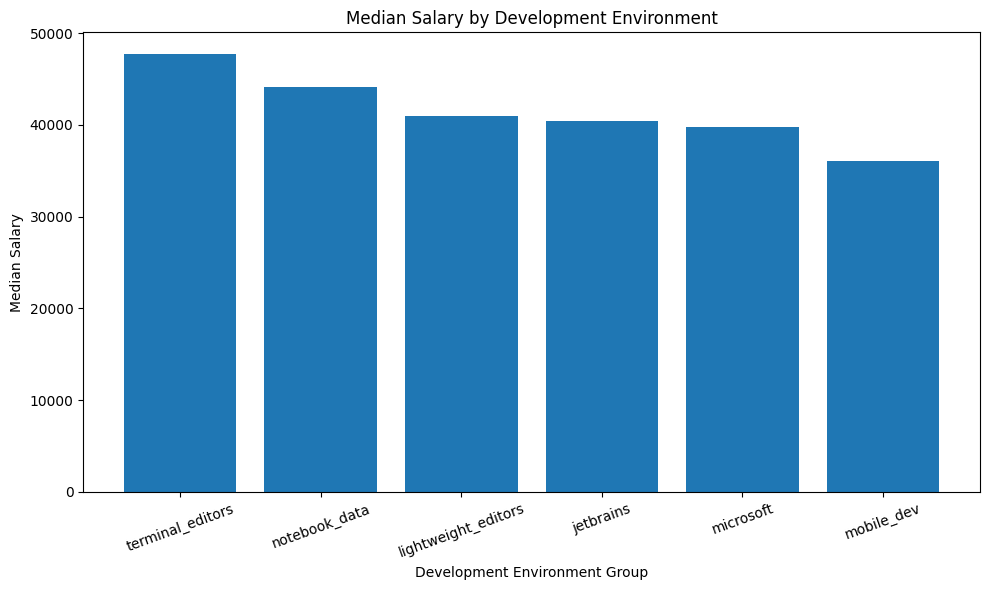

In [59]:
plt.figure(figsize=(10, 6))

plt.bar(
    median_df["group"],
    median_df["median_salary"]
)

plt.xlabel("Development Environment Group")
plt.ylabel("Median Salary")
plt.title("Median Salary by Development Environment")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [60]:
cols_to_remove =  ['dev_environments'
]

# Execute the drop
df = df.drop(columns=cols_to_remove)


In [61]:
df.columns

Index(['annual_pay_usd', 'region', 'employment_type', 'work_location',
       'education', 'coding_years_professional', 'dev_role', 'company_size',
       'prog_languages', 'work_os', 'uses_ai', 'has_influence', 'frontend',
       'backend', 'systems', 'data', 'scripting_devops', 'jetbrains',
       'microsoft', 'terminal_editors', 'mobile_dev', 'notebook_data',
       'lightweight_editors'],
      dtype='object')

Feature selection

In [62]:
fdfig = px.histogram(
    df,
    x="annual_pay_usd",
    nbins=100,
    title="Annual Salary Distribution (USD)",
    labels={"annual.pay.usd": "Salary (USD)", "count": "Frequency"}
)

fig.show()

Feature selection

In [63]:
# Filter the view to under $300k (or wherever the bulk ends)
fig = px.histogram(df, x='annual_pay_usd', title="Annual Salary Distribution")
fig.update_layout(xaxis_range=[0, 300000])
fig.show()

In [64]:
df['log_annual_pay'] = np.log1p(df['annual_pay_usd'])

fig = px.histogram(df, x='log_annual_pay', title="Log-Transformed Salary Distribution")
fig.show()


In [65]:
# Example: Testing if 'company_size' impacts 'annual_pay_usd'
groups = [group['annual_pay_usd'].values for name, group in df.groupby('company_size')]
f_stat, p_val = stats.f_oneway(*groups)

print(f"P-value: {p_val}")
if p_val < 0.05:
    print("Keep feature: Significant differences in salary across groups.")

P-value: 0.07398000330086348


In [66]:
df.drop(columns=['prog_languages'], inplace=True)

In [67]:
df['employment_type'].value_counts()

,count
employment_type,
Full-time,2069
Freelance/Self-employed,292
Student,68
Part-time,33
Job-seeking,12


In [68]:
df.columns

Index(['annual_pay_usd', 'region', 'employment_type', 'work_location',
       'education', 'coding_years_professional', 'dev_role', 'company_size',
       'work_os', 'uses_ai', 'has_influence', 'frontend', 'backend', 'systems',
       'data', 'scripting_devops', 'jetbrains', 'microsoft',
       'terminal_editors', 'mobile_dev', 'notebook_data',
       'lightweight_editors', 'log_annual_pay'],
      dtype='object')

In [69]:
df['work_os']

,work_os
0,OS_Tier_1_Premium
1,OS_Tier_2_Standard_Linux
2,OS_Tier_4_Specialized
3,OS_Tier_1_Premium
4,OS_Tier_2_Standard_Linux
...,...
2507,OS_Tier_3_Windows_Base
2508,OS_Tier_2_Standard_Linux
2509,OS_Tier_3_Windows_Base
2510,OS_Tier_1_Premium


In [70]:
# 1. Define categorical columns to test
categorical_columns = [
    'work_location', 'dev_role', 'region',
    'education', 'employment_type','company_size','work_os'
]

# 2. Initialize a list to hold your academic test results
test_results = []

for col in categorical_columns:
    # Group the log salaries by each unique category value in the column
    groups = [group['log_annual_pay'].values for name, group in df.groupby(col)]

    # Ensure the column actually has multiple categories to compare
    if len(groups) > 1:
        # Run One-Way ANOVA
        f_stat, anova_p = stats.f_oneway(*groups)

        # Run Kruskal-Wallis Test
        h_stat, kruskal_p = stats.kruskal(*groups)

        # Determine academic selection verdict (Keep if either p-value < 0.05)
        verdict = "KEEP (Significant)" if (anova_p < 0.05 or kruskal_p < 0.05) else "DROP (Insignificant)"

        test_results.append({
            'Categorical Column': col,
            'ANOVA p-value': f"{anova_p:.4e}",
            'Kruskal p-value': f"{kruskal_p:.4e}",
            'Selection Decision': verdict
        })

# 3. Display the final feature selection summary table
results_df = pd.DataFrame(test_results).sort_values(by='ANOVA p-value')
print("\n=== FINAL CATEGORICAL FEATURE SELECTION VERDICT ===")
print(results_df.to_string(index=False))


=== FINAL CATEGORICAL FEATURE SELECTION VERDICT ===
Categorical Column ANOVA p-value Kruskal p-value Selection Decision
     work_location    1.3513e-01      4.7018e-04 KEEP (Significant)
            region    1.3956e-57      1.4172e-46 KEEP (Significant)
           work_os    1.9108e-04      7.3862e-13 KEEP (Significant)
      company_size    4.4870e-02      4.4752e-04 KEEP (Significant)
         education    4.6284e-02      4.0831e-06 KEEP (Significant)
   employment_type    7.4978e-15      3.5242e-30 KEEP (Significant)
          dev_role    8.3586e-06      9.8626e-11 KEEP (Significant)


In [71]:
original_binary_cols = [
       'uses_ai', 'has_influence', 'frontend', 'backend', 'systems', 'data',
       'scripting_devops', 'jetbrains', 'microsoft', 'terminal_editors',
       'mobile_dev', 'notebook_data', 'lightweight_editors']

# 3. Define the validated parent categorical columns
categorical_cols =  [
    'work_location', 'dev_role', 'region',
    'education', 'employment_type','company_size','work_os'
]


# 4. Transform categories into binary dummies and drop the first group
X_categorical_encoded = pd.get_dummies(df[categorical_cols], drop_first=True, dtype=int)

# 5. MERGE THEM TOGETHER into a single Master Binary Matrix (47 features total)
X_master_binary = pd.concat([df[original_binary_cols], X_categorical_encoded], axis=1)

# 6. Compute the absolute Pearson correlation matrix
master_corr_matrix = X_master_binary.corr().abs()

# 7. Check if any distinct features have a dangerously high correlation (> 0.70)
upper_tri = master_corr_matrix.where(np.triu(np.ones(master_corr_matrix.shape), k=1).astype(bool))
high_correlations = [
    (column, row, upper_tri.loc[row, column])
    for column in upper_tri.columns
    for row in upper_tri.index
    if upper_tri.loc[row, column] > 0.70
]

if len(high_correlations) == 0:
    print("Verdict: Excellent! All 47 combined binary features are completely independent.")
    print("There are no severe cross-correlations (> 0.70) between your dummies and raw binary flags.")
else:
    print("[WARNING] The following binary variables are highly collinear:")
    for col, row, val in high_correlations:
        print(f" - '{row}' and '{col}' have a correlation of {val:.3f}")

# 8. Generate the Ultimate Combined Heatmap Visual
fig = px.imshow(
    master_corr_matrix,
    aspect="auto",
    color_continuous_scale="Viridis",
    zmin=0,
    zmax=1,
    title="Comprehensive Multicollinearity Matrix: Combined Binary & Dummy Features",
    labels=dict(color="Absolute Correlation")
)

fig.update_layout(
    width=1100,
    height=1000,
    xaxis_tickangle=-45,
    margin=dict(l=150, r=20, t=80, b=150)
)

fig.show()
fig.write_html("my_plot.html")

Verdict: Excellent! All 47 combined binary features are completely independent.
There are no severe cross-correlations (> 0.70) between your dummies and raw binary flags.


In [72]:
df['coding_years_professional']

,coding_years_professional
0,16.0
1,14.0
2,0.0
3,6.0
4,4.0
...,...
2507,10.0
2508,4.0
2509,3.0
2510,14.0


In [73]:
median_years = df['coding_years_professional'].median()
df['coding_years_professional'] = df['coding_years_professional'].fillna(median_years)

In [74]:
fig = px.histogram(df, x='coding_years_professional', title="coding_years_professional Distribution")
fig.show()



In [75]:
df['coding_years_log'] = np.log1p(df['coding_years_professional'])
fig = px.histogram(df, x='coding_years_log', title="coding_years_log Distribution")
fig.show()



In [76]:
#df.drop(columns=['coding_years_professional','annual_pay_usd'],inplace=True)

In [77]:
print(df.isna().sum())

annual_pay_usd               0
region                       0
employment_type              0
work_location                0
education                    0
coding_years_professional    0
dev_role                     0
company_size                 0
work_os                      0
uses_ai                      0
has_influence                0
frontend                     0
backend                      0
systems                      0
data                         0
scripting_devops             0
jetbrains                    0
microsoft                    0
terminal_editors             0
mobile_dev                   0
notebook_data                0
lightweight_editors          0
log_annual_pay               0
coding_years_log             0
dtype: int64


In [78]:
df = df.drop(columns=[

    'jetbrains',
    'microsoft',
    'terminal_editors',
    'notebook_data',
    'lightweight_editors'
], errors='ignore')

In [79]:
df.columns

Index(['annual_pay_usd', 'region', 'employment_type', 'work_location',
       'education', 'coding_years_professional', 'dev_role', 'company_size',
       'work_os', 'uses_ai', 'has_influence', 'frontend', 'backend', 'systems',
       'data', 'scripting_devops', 'mobile_dev', 'log_annual_pay',
       'coding_years_log'],
      dtype='object')

In [80]:
df_cleaned = df.copy()
df_cleaned.to_csv('cleaned_data1.csv', index=False)

In [81]:
# FEATURES & TARGET

X = df_cleaned.drop(columns=[
    'annual_pay_usd',
    'log_annual_pay',
    'coding_years_professional'
])

y = df_cleaned['log_annual_pay']

# COLUMN TYPES

num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object', 'category', 'bool']).columns

# PREPROCESSING

preprocessor = ColumnTransformer([

    ('num',
     StandardScaler(),
     num_cols),

    ('cat',
     OneHotEncoder(
         handle_unknown='ignore',
         drop='first'   # Avoid multicollinearity
     ),
     cat_cols)
])

# PIPELINES

svr_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('feature_selection', SelectKBest(f_regression)),
    ('model', SVR())
])

knn_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('feature_selection', SelectKBest(f_regression)),
    ('model', KNeighborsRegressor())
])

# HYPERPARAMETER GRIDS

svr_param_grid = {
    'feature_selection__k': [20, 30, 40, 'all'],

    'model__kernel': ['rbf'],

    'model__C': [1, 10, 50],

    'model__epsilon': [0.01, 0.1, 0.5],

    'model__gamma': ['scale', 'auto']
}

knn_param_grid = {
    'feature_selection__k': [20, 30, 40, 'all'],

    'model__n_neighbors': [5, 10, 15],

    'model__weights': ['uniform', 'distance'],

    'model__metric': ['euclidean', 'manhattan']
}

# CROSS VALIDATION

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# GRID SEARCH - SVR

svr_grid = GridSearchCV(
    estimator=svr_pipeline,

    param_grid=svr_param_grid,

    scoring='neg_root_mean_squared_error',

    cv=cv,

    n_jobs=-1,

    verbose=2
)

svr_grid.fit(X, y)

# BEST SVR MODEL

best_svr = svr_grid.best_estimator_

print("\n===== BEST SVR PARAMETERS =====")
print(svr_grid.best_params_)

print("\n===== BEST SVR CV RMSE =====")
print(-svr_grid.best_score_)

# GRID SEARCH - KNN

knn_grid = GridSearchCV(
    estimator=knn_pipeline,

    param_grid=knn_param_grid,

    scoring='neg_root_mean_squared_error',

    cv=cv,

    n_jobs=-1,

    verbose=2
)

knn_grid.fit(X, y)

# BEST KNN MODEL

best_knn = knn_grid.best_estimator_

print("\n===== BEST KNN PARAMETERS =====")
print(knn_grid.best_params_)

print("\n===== BEST KNN CV RMSE =====")
print(-knn_grid.best_score_)

# TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# TRAIN BEST MODELS

best_svr.fit(X_train, y_train)
best_knn.fit(X_train, y_train)

# PREDICTIONS

svr_preds_log = best_svr.predict(X_test)
knn_preds_log = best_knn.predict(X_test)

# CONVERT BACK TO REAL SALARY

real_salary = np.expm1(y_test)

svr_preds_salary = np.expm1(svr_preds_log)
knn_preds_salary = np.expm1(knn_preds_log)

# EVALUATION FUNCTION

def evaluate_model(name, y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    r2 = r2_score(y_true, y_pred)

    print(f"\n===== {name} =====")
    print(f"MAE  : ${mae:,.2f}")
    print(f"RMSE : ${rmse:,.2f}")
    print(f"R2   : {r2:.4f}")

# FINAL RESULTS

evaluate_model(
    'TUNED SVR',
    real_salary,
    svr_preds_salary
)

evaluate_model(
    'TUNED KNN',
    real_salary,
    knn_preds_salary
)

Fitting 6 folds for each of 72 candidates, totalling 432 fits

===== BEST SVR PARAMETERS =====
{'feature_selection__k': 'all', 'model__C': 10, 'model__epsilon': 0.5, 'model__gamma': 'auto', 'model__kernel': 'rbf'}

===== BEST SVR CV RMSE =====
1.4586908079122745
Fitting 6 folds for each of 48 candidates, totalling 288 fits

===== BEST KNN PARAMETERS =====
{'feature_selection__k': 20, 'model__metric': 'manhattan', 'model__n_neighbors': 15, 'model__weights': 'uniform'}

===== BEST KNN CV RMSE =====
1.463443629568194

===== TUNED SVR =====
MAE  : $33,623.55
RMSE : $217,097.29
R2   : 0.0027

===== TUNED KNN =====
MAE  : $37,220.54
RMSE : $218,948.97
R2   : -0.0143


In [82]:
X = df_cleaned.drop(columns=[
    'annual_pay_usd',
    'log_annual_pay',
    'coding_years_professional'
])

y = df_cleaned['log_annual_pay']


num_cols = X.select_dtypes(include=['int64', 'float64']).columns

cat_cols = X.select_dtypes(
    include=['object', 'category', 'bool']
).columns


preprocessor = ColumnTransformer([

    ('num',
     StandardScaler(),
     num_cols),

    ('cat',
     OneHotEncoder(
         handle_unknown='ignore',
         drop='first'   # Avoid multicollinearity
     ),
     cat_cols)
])


linear_pipeline = Pipeline([

    ('preprocessing', preprocessor),

    ('feature_selection',
     SelectKBest(f_regression)),

    ('model',
     LinearRegression())
])

# HYPERPARAMETERS


linear_param_grid = {
    'feature_selection__k': [20, 30, 40, 'all']
}

# CROSS VALIDATION

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# GRID SEARCH

linear_grid = GridSearchCV(

    estimator=linear_pipeline,

    param_grid=linear_param_grid,

    scoring='neg_root_mean_squared_error',

    cv=cv,

    n_jobs=-1,

    verbose=2
)

# TRAIN

linear_grid.fit(X, y)

# BEST MODEL

best_linear = linear_grid.best_estimator_

print("\n===== BEST PARAMETERS =====")
print(linear_grid.best_params_)

print("\n===== BEST CV RMSE (LOG SPACE) =====")
print(-linear_grid.best_score_)

# TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# FIT BEST MODEL

best_linear.fit(X_train, y_train)

# PREDICT

preds_log = best_linear.predict(X_test)

# CONVERT BACK TO REAL SALARY

preds_salary = np.expm1(preds_log)

real_salary = np.expm1(y_test)

# METRICS

linear_mae = mean_absolute_error(
    real_salary,
    preds_salary
)

linear_rmse = np.sqrt(
    mean_squared_error(
        real_salary,
        preds_salary
    )
)

linear_r2 = r2_score(
    real_salary,
    preds_salary
)

# RESULTS

print("\n===== REAL SALARY METRICS =====")

print(f"MAE  : ${linear_mae:,.2f}")

print(f"RMSE : ${linear_rmse:,.2f}")

print(f"R2   : {linear_r2:.4f}")

Fitting 5 folds for each of 4 candidates, totalling 20 fits

===== BEST PARAMETERS =====
{'feature_selection__k': 40}

===== BEST CV RMSE (LOG SPACE) =====
1.4054186813262062

===== REAL SALARY METRICS =====
MAE  : $35,285.26
RMSE : $217,773.62
R2   : -0.0035


In [83]:
df_test = pd.read_csv('test.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'test.csv'

In [ ]:
df_test.info()

In [ ]:
df_pred = df_test.copy()

# Consistent column renaming: Replace '.' with '_' in all column names first
df_pred.columns = df_pred.columns.str.replace('.', '_', regex=False)

# Drop columns that were dropped in training data
drop_cols_training = [
    'job_satisfaction',
    'age_group',
    'experience_years',
    'is_dev_professional',
    'cloud_hosting',
    'daily_answer_time',
    'daily_search_time',
    'first_help_source',
    'other_tech',
    'ai_tools_used',
    'ai_complex_rating',
    'ai_trust',
    'web_frameworks',
    'cloud_platforms',
    'ai_search_tools',
    'ai_sentiment',
    'ai_job_threat',
    'databases',
    'industry',
    'project_mgmt_tools',
    'dev_tools',
    'people_manager',
    'comm_tools',
    'build_vs_buy',
    'how_learned_coding',
    'personal_os',
    'side_coding',
    'coding_years_total'
    # Removed 'id' from this list, as it's needed for output
]

df_pred = df_pred.drop(columns=drop_cols_training, errors='ignore')


# Re-apply specific transformations from training data

# 1. Region Grouping (need to define rare_regions from training logic)
region_counts_training = pd.read_csv('/content/drive/MyDrive/UW/ML1/train.csv')['region'].value_counts()
rare_regions = region_counts_training[region_counts_training <= 30].index
df_pred['region'] = df_pred['region'].apply(lambda x: 'Other' if x in rare_regions else x)

# 2. Education Grouping
def group_education(edu):
    if 'Master’s' in edu:
        return 'Graduate (Master)'
    elif 'Professional' in edu:
        return 'Post-Graduate (PhD/MD)'
    elif 'Bachelor’s' in edu:
        return 'Undergraduate (Bachelor)'
    elif 'Some college' in edu or 'Associate' in edu:
        return 'Undergrad / Technical'
    else:
        return 'Secondary or lower'
df_pred['education'] = df_pred['education'].apply(group_education)

# 3. Dev Role Grouping
# def group_dev_role(role):
#     role = str(role).lower()
#     if any(x in role for x in ['back-end', 'devops', 'cloud', 'infrastructure', 'administrator']):
#         return 'Back-end & Infrastructure'
#     elif any(x in role for x in ['full-stack', 'front-end']):
#         return 'Full-stack & Front-end'
#     elif any(x in role for x in ['data', 'machine learning', 'ai', 'scientist', 'analyst']):
#         return 'Data & AI'
#     elif any(x in role for x in ['mobile', 'desktop', 'embedded', 'game', 'graphics', 'blockchain']):
#         return 'Mobile & Specialized App'
#     elif any(x in role for x in ['manager', 'executive', 'vp', 'c-suite']):
#         return 'Leadership & Management'
#     elif 'test' in role or 'qa' in role:
#         return 'QA & Testing'
#     elif 'research' in role:
#         return 'Research'
#     else:
#         return 'Other '

def group_dev_role_better(role):
    role = str(role).lower()

    if any(x in role for x in [
        'senior executive', 'executive', 'c-suite', 'vp',
        'engineering manager', 'manager', 'product manager'
    ]):
        return 'Leadership & Management'

    elif any(x in role for x in [
        'data scientist', 'machine learning', 'ai',
        'data engineer', 'data analyst', 'analytics'
    ]):
        return 'Data & AI'

    elif any(x in role for x in [
        'devops', 'cloud', 'infrastructure',
        'site reliability', 'sre', 'system administrator'
    ]):
        return 'DevOps & Cloud'

    elif any(x in role for x in [
        'back-end', 'backend', 'server'
    ]):
        return 'Backend'

    elif any(x in role for x in [
        'front-end', 'frontend'
    ]):
        return 'Frontend'

    elif any(x in role for x in [
        'full-stack', 'full stack'
    ]):
        return 'Full-stack'

    elif any(x in role for x in [
        'mobile', 'android', 'ios'
    ]):
        return 'Mobile'

    elif any(x in role for x in [
        'embedded', 'iot', 'hardware'
    ]):
        return 'Embedded & Hardware'

    elif any(x in role for x in [
        'game', 'graphics', 'blockchain'
    ]):
        return 'Specialized Software'

    elif any(x in role for x in [
        'qa', 'test', 'quality'
    ]):
        return 'QA & Testing'

    elif any(x in role for x in [
        'research', 'academic'
    ]):
        return 'Research'

    elif any(x in role for x in [
        'student', 'educator', 'teacher'
    ]):
        return 'Education / Student'

    else:
        return 'Other'
df_pred['dev_role'] = df_pred['dev_role'].apply(group_dev_role_better)

# 4. Company Size Mapping
def map_company_size(size):
    if size in ['Just me - I am a freelancer, sole proprietor, etc.', '2 to 9 employees']:
        return 1 # Small/Freelance
    elif size == '10 to 19 employees':
        return 2 # Small-Mid
    elif size == '20 to 99 employees':
        return 3 # Mid
    elif size in ['100 to 499 employees', '500 to 999 employees']:
        return 4 # Large
    elif size in ['1,000 to 4,999 employees', '5,000 to 9,999 employees', '10,000 or more employees']:
        return 5 # Enterprise
    else:
        return 3 # Default for 'I don’t know' (The Mode: 20-99)
df_pred['company_size'] = df_pred['company_size'].apply(map_company_size)

# 5. `uses_ai` Transformation
df_pred['uses_ai'] = df_pred['uses_ai'].map({'Yes': 1, 'No': 0}).fillna(0).astype(int)

# 6. `work_os` Grouping
def group_os(os):
    os = str(os)
    if os in ['MacOS', 'Arch', 'Debian']:
        return 'OS_Tier_1_Premium'
    elif any(x in os for x in ['Red Hat', 'Fedora', 'Ubuntu', 'Android']):
        return 'OS_Tier_2_Standard_Linux'
    elif os in ['Windows', 'Other', 'Unknown']:
        return 'OS_Tier_3_Windows_Base'
    else:
        return 'OS_Tier_4_Specialized'
# First, handle multi-select and fillna like in training for work_os
df_pred['work_os'] = df_pred['work_os'].fillna('Unknown').str.split(';').str[0]
df_pred['work_os'] = df_pred['work_os'].apply(group_os)

# 7. `tech_purchase_influence` to `has_influence` Transformation
# Fill null values with mode (assuming 'I have some influence' was mode from training)
df_pred['tech_purchase_influence'] = df_pred['tech_purchase_influence'].fillna('I have some influence')
df_pred['has_influence'] = df_pred['tech_purchase_influence'].apply(
    lambda x: 1 if x in ['I have a great deal of influence'] else 0
)
df_pred.drop(columns=['tech_purchase_influence'], inplace=True)

# 8. `prog_languages` related flags
language_groups = {
    "frontend": ["HTML/CSS", "JavaScript", "TypeScript"],
    "backend": ["Python", "Java", "PHP", "C#", "Go", "Ruby"],
    "systems": ["C", "C++", "Rust"],
    "data": ["SQL", "R", "Scala"],
    "scripting_devops": ["Bash/Shell (all shells)", "PowerShell"]
}

df_pred["prog_languages"] = (
    df_pred["prog_languages"]
    .astype(str)
    .str.strip("[]")
    .str.split(", ")
)
df_pred["prog_languages"] = df_pred["prog_languages"].apply(
    lambda x: [i.strip().strip("'").strip('"') for i in x] if isinstance(x, list) else []
)

for group, langs in language_groups.items():
    df_pred[group] = df_pred["prog_languages"].apply(
        lambda x: int(any(lang in x for lang in langs))
    )
# Drop the original prog_languages column as it's no longer needed after creating flags
df_pred = df_pred.drop(columns=['prog_languages'])

# 9. `dev_environments` related flags (only mobile_dev was kept from these in training)
dev_env_groups = {
    "jetbrains": ["IntelliJ IDEA", "PyCharm", "WebStorm", "PhpStorm", "DataGrip", "Rider", "CLion", "GoLand"],
    "microsoft": ["Visual Studio", "Visual Studio Code"],
    "terminal_editors": ["Vim", "Neovim", "Emacs"],
    "mobile_dev": ["Android Studio", "Xcode"],
    "notebook_data": ["Jupyter Notebook/JupyterLab", "RStudio"],
    "lightweight_editors": ["Notepad++", "Sublime Text"]
}

df_pred["dev_environments"] = (
    df_pred["dev_environments"]
    .fillna("")
    .str.split(";")
)

for group, envs in dev_env_groups.items():
    df_pred[group] = df_pred["dev_environments"].apply(
        lambda x: int(any(env.strip() in envs for env in x))
    )
# After creating flags, drop the original dev_environments and the temporary flags
df_pred = df_pred.drop(columns=[
    'dev_environments',
    'jetbrains',
    'microsoft',
    'terminal_editors',
    'notebook_data',
    'lightweight_editors'
])


# Handle missing values for numerical columns
# `coding_years_professional` was imputed with median in training
median_coding_years_professional = df['coding_years_professional'].median() # Get median from the training df
df_pred['coding_years_professional'] = df_pred['coding_years_professional'].fillna(median_coding_years_professional)

# Create log transformed coding years
df_pred['coding_years_log'] = np.log1p(df_pred['coding_years_professional'])

# FINAL FEATURES
# MUST MATCH TRAINING FEATURES in exact order for preprocessor to work correctly
X_pred = df_pred[[
    'region',
    'employment_type',
    'work_location',
    'education',
    'dev_role',
    'company_size',
    'work_os',
    'uses_ai',
    'has_influence',
    'frontend',
    'backend',
    'systems',
    'data',
    'scripting_devops',
    'mobile_dev',
    'coding_years_log'
]]

# PREDICT LOG SALARY
preds_log = best_svr.predict(X_pred)

# CONVERT BACK TO REAL SALARY
predicted_salary = np.expm1(preds_log)

# SAVE RESULTS
df_pred['predicted_salary_usd'] = predicted_salary

# OUTPUT
print(df_pred[['id', 'predicted_salary_usd']].head())

# SAVE
df_pred.to_csv(
    'linear_salary_predictions.csv',
    index=False
)

In [ ]:
mean_predicted_salary = df_pred['predicted_salary_usd'].mean()
print(f"Mean of predicted salary: ${mean_predicted_salary:,.2f}")

In [ ]:
df_pred[['id', 'predicted_salary_usd']].to_csv('predicted_salary_results.csv', index=False)
